# Dynamic Facial Expression Recognition with Facial Expression Activations

In [1]:
# Set up notebook
name_of_this_notebook = 'lstm.ipynb'

BATCH_SIZE = 32
LR = 5e-4
SEED = 31

experiment_name = f'{name_of_this_notebook[:-6]}-b-{BATCH_SIZE}-lr-{LR:.0e}-seed-{SEED}'

In [2]:
import re
import ipykernel.iostream

TF_LOG_FILTER_PATTERNS = [
    r'ptx\d+.*is not a recognized feature for this target',
    r'is not a recognized feature for this target \(ignoring feature\)',
    r'\(ignoring feature\)',
    r'successful NUMA node read from SysFS had negative value \(-1\)',
    r'gpu_timer\.cc:114\] Skipping the delay kernel, measurement accuracy will be reduced',
]

KERAS_PROGRESS_PATTERNS = [
    r'ms/step',
    r's/step',
    r'ETA:',
    r'\d+/\d+ \[',   # 12/64 [===>...]
]

_original_write = ipykernel.iostream.OutStream.write

def _filtered_write(self, msg, *args, **kwargs):
    text = str(msg)

    if any(re.search(p, text) for p in KERAS_PROGRESS_PATTERNS):
        _original_write(self, text, *args, **kwargs)
        return

    buf = getattr(self, '_tf_log_filter_buf', '')
    buf += text

    if '\n' not in buf:
        setattr(self, '_tf_log_filter_buf', buf)
        return

    lines = buf.splitlines(keepends=True)
    if not buf.endswith('\n'):
        incomplete = lines.pop()
    else:
        incomplete = ''

    for line in lines:
        if any(re.search(p, line) for p in TF_LOG_FILTER_PATTERNS):
            continue
        _original_write(self, line, *args, **kwargs)

    setattr(self, '_tf_log_filter_buf', incomplete)

ipykernel.iostream.OutStream.write = _filtered_write

print('Notebook log filter installed (targeted, keeps Keras steps).')

Notebook log filter installed (targeted, keeps Keras steps).


In [3]:
# import keras

# keras.mixed_precision.set_global_policy('mixed_float16')

In [4]:
# Ensure Determinism
import random
import numpy as np
import tensorflow as tf
import keras


random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

2025-11-14 10:39:22.508649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-14 10:39:22.517065: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-14 10:39:22.519616: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
# Ensure GPU works as expected
print('TensorFlow Version:', tf.__version__, ';', 'Keras Version:', keras.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Number of GPUs detected: {len(gpus)}')
    for gpu in gpus:
        device_details = tf.config.experimental.get_device_details(gpu)
        print(f'Physical Device: {gpu.name}')
        print(f'Name: {device_details['device_name']}')
        print(f'Compute Capability: {device_details['compute_capability']}')
else:
    print('No GPUs were detected.')

TensorFlow Version: 2.17.0 ; Keras Version: 3.12.0
Number of GPUs detected: 1
Physical Device: /physical_device:GPU:0
Name: NVIDIA GeForce RTX 5090
Compute Capability: (12, 0)


## Prepare Data

In [6]:
from pathlib import Path
import pandas as pd

dataset_path = Path(r'/workspace/datasets/emoji-hero-vr-db-dfea-as-csv')

train_df = pd.read_csv(str(dataset_path / 'training_set.csv'))
print('train_df.shape:', train_df.shape)
val_df = pd.read_csv(str(dataset_path / 'validation_set.csv'))
print('val_df.shape:', val_df.shape)
test_df = pd.read_csv(str(dataset_path / 'test_set.csv'))
print('test_df.shape:', test_df.shape)
print('Columns:', test_df.columns)

train_df.shape: (28920, 66)
val_df.shape: (11550, 66)
test_df.shape: (11340, 66)
Columns: Index(['sequence_id', 'timestamp', 'BrowLowererL', 'BrowLowererR',
       'CheekPuffL', 'CheekPuffR', 'CheekRaiserL', 'CheekRaiserR',
       'CheekSuckL', 'CheekSuckR', 'ChinRaiserB', 'ChinRaiserT', 'DimplerL',
       'DimplerR', 'EyesClosedL', 'EyesClosedR', 'EyesLookDownL',
       'EyesLookDownR', 'EyesLookLeftL', 'EyesLookLeftR', 'EyesLookRightL',
       'EyesLookRightR', 'EyesLookUpL', 'EyesLookUpR', 'InnerBrowRaiserL',
       'InnerBrowRaiserR', 'JawDrop', 'JawSidewaysLeft', 'JawSidewaysRight',
       'JawThrust', 'LidTightenerL', 'LidTightenerR', 'LipCornerDepressorL',
       'LipCornerDepressorR', 'LipCornerPullerL', 'LipCornerPullerR',
       'LipFunnelerLB', 'LipFunnelerLT', 'LipFunnelerRB', 'LipFunnelerRT',
       'LipPressorL', 'LipPressorR', 'LipPuckerL', 'LipPuckerR',
       'LipStretcherL', 'LipStretcherR', 'LipSuckLB', 'LipSuckLT', 'LipSuckRB',
       'LipSuckRT', 'LipTightenerL', '

In [7]:
def prepare_data(df):
    grouped_by_sequence = df.groupby('sequence_id')

    sequences = []
    labels = []

    for sequence_id, group in grouped_by_sequence:
        sorted_group = group.sort_values(by='timestamp')
        sequences.append(sorted_group.iloc[:, 2:-1].values)  # Select all feature columns
        labels.append(sorted_group.iloc[0, -1])  # Select one label per group

    X = np.array(sequences)
    y = np.array(labels)
    return X, y


X_train, y_train = prepare_data(train_df)
X_val, y_val = prepare_data(val_df)
X_test, y_test = prepare_data(test_df)

In [8]:
def create_dataset(X, y, batch_size, reshuffle_each_iteration):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    dataset = dataset.shuffle(len(X), seed=SEED, reshuffle_each_iteration=reshuffle_each_iteration).batch(batch_size)
    return dataset


train_dataset = create_dataset(X_train, y_train, BATCH_SIZE, True)
val_dataset = create_dataset(X_val, y_val, BATCH_SIZE, False)
test_dataset = create_dataset(X_test, y_test, BATCH_SIZE, False)

### Prepare Class Frequencies for Loss Function 

In [9]:
id_to_emotion = {
    0: 'Anger',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happiness',
    4: 'Neutral',
    5: 'Sadness',
    6: 'Surprise',
}

class_frequencies = train_df['Label'].value_counts().sort_index()
print(f'--- Training Set Class Frequencies ---')
for class_id, frequency in class_frequencies.items():
    print(f'{class_id} - {id_to_emotion[class_id]:<9} : {frequency:>8}')


def scaled_inverse_freq_weights(counts: pd.Series) -> dict[int, float]:
    inv = 1.0 / counts
    # Scale so that the center is 1
    w = inv * (len(counts) / inv.sum())
    return {int(k): float(v) for k, v in w.items()}

class_weights = scaled_inverse_freq_weights(class_frequencies)
print(f'\nClass Weights:\n {class_weights}')

--- Training Set Class Frequencies ---
0 - Anger     :     1980
1 - Disgust   :     3060
2 - Fear      :     3150
3 - Happiness :     5730
4 - Neutral   :     5910
5 - Sadness   :     3930
6 - Surprise  :     5160

Class Weights:
 {0: 1.8211414828477057, 1: 1.1783856653720448, 2: 1.1447175035042723, 3: 0.6292949626594166, 4: 0.6101286186190283, 5: 0.9175216631141113, 6: 0.6988101038834219}


## Define Network Architecture

In [10]:
from keras.layers import Input, Dense, Dropout, LSTM, Normalization, SpatialDropout1D, TimeDistributed
from keras.models import Model

norm = Normalization(axis=-1, name='norm_in')
norm.adapt(X_train.reshape(-1, X_train.shape[-1]))  # shape: (N*T, D)

fea_input = Input(shape=(30, 63), name='fea_input')
# x = TimeDistributed(Dense(256, activation='relu'))(fea_input)
x = norm(fea_input)
x = SpatialDropout1D(0.25, name='spatial_dropout')(x)
# x = Dropout(0.5, name='fea_dropout_0')(x)
x = LSTM(128, dropout=0.05)(x)
x = Dropout(0.2, name='fea_dropout_1')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2, name='fea_dropout_2')(x)
# x = Dense(64, activation='relu')(x)
# x = Dropout(0.4, name='fea_dropout_3')(x)
fau_output = Dense(len(id_to_emotion), activation='softmax')(x)

fea_model = Model(inputs=fea_input, outputs=fau_output)
fea_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fea_input (InputLayer)          │ (None, 30, 63)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_in (Normalization)         │ (None, 30, 63)         │           127 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 30, 63)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_1 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fea_dropout_2 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,846 (452.53 KB)

 Trainable params: 115,719 (452.03 KB)

 Non-trainable params: 127 (512.00 B)

## Train the Network

In [11]:
from datetime import datetime
from keras.optimizers import Adam
from keras.callbacks import CSVLogger, ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

optimizer = Adam(learning_rate=LR)

timestamp = datetime.now().strftime("%Y%m%d-%H%M")
checkpoint_dir = Path(f'{timestamp}-checkpoint-{experiment_name}')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
model_checkpoint_callback = ModelCheckpoint(filepath=f'{checkpoint_dir / "fea_model"}.keras',
                                            save_weights_only=False,
                                            monitor='val_loss',
                                            mode='min',
                                            save_best_only=True)

early_stopping_callback = EarlyStopping(monitor='val_loss', mode='min', patience=12, restore_best_weights=True)
reduce_lr_callback = ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=3, min_lr=1e-6)
csv_logger = CSVLogger(str(checkpoint_dir / 'training_log.csv'), append=False)
callbacks = [model_checkpoint_callback, early_stopping_callback, reduce_lr_callback]

fea_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
history = fea_model.fit(train_dataset,
                        validation_data=val_dataset,
                        class_weight=class_weights,
                        callbacks=callbacks,
                        epochs=200)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4357 - loss: 1.4016 - val_accuracy: 0.6961 - val_loss: 1.0836 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7365 - loss: 0.8936 - val_accuracy: 0.7532 - val_loss: 0.7073 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7573 - loss: 0.6705 - val_accuracy: 0.7844 - val_loss: 0.6057 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7967 - loss: 0.5681 - val_accuracy: 0.7896 - val_loss: 0.5777 - learning_rate: 5.0000e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8143 - loss: 0.5151 - val_accuracy: 0.8078 - val_loss: 0.5541 - learning_rate: 5.0000e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8102 - loss: 0.4920 - val_accuracy: 0.7740 - val_loss: 0.5643 - learning_rate: 5.0000e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8402

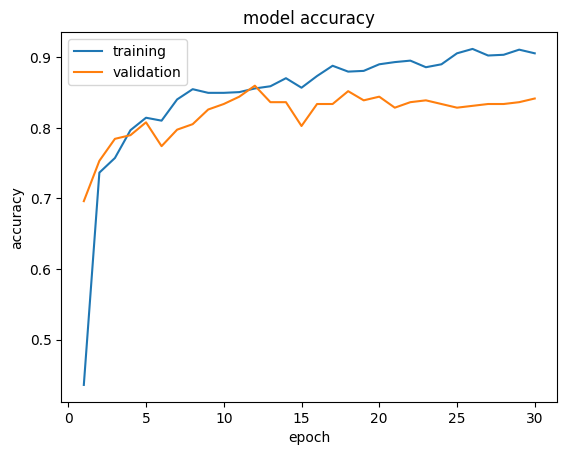

In [13]:
import matplotlib.pyplot as plt


def plot_and_save_combined_history(hist, checkpoint_dir):
    acc = hist.history["accuracy"]
    val_acc = hist.history["val_accuracy"]

    epochs = range(1, len(acc) + 1)

    plt.plot(epochs, acc, label="training")
    plt.plot(epochs, val_acc, label="validation")
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(loc="upper left")

    plt.savefig(str(checkpoint_dir / 'training_history.png'))

    plt.show()


plot_and_save_combined_history(history, checkpoint_dir)

## Evaluate Model

In [14]:
from keras.models import load_model

best_checkpoint = str(checkpoint_dir / "fea_model.keras")
best_model = load_model(best_checkpoint)

In [15]:
val_loss, val_acc = best_model.evaluate(val_dataset)
print(f"Validation accuracy: {val_acc}\nValidation loss: {val_loss}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8519 - loss: 0.4712  
Validation accuracy: 0.8519480228424072
Validation loss: 0.4712221324443817


In [16]:
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7831 - loss: 0.8879
Test accuracy: 0.7830687761306763


In [17]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_vectors = best_model.predict(test_dataset)
y_pred = np.argmax(y_pred_vectors, axis=1)
y_true = np.concatenate([y for _, y in test_dataset], axis=0)

report = classification_report(y_true, y_pred, target_names=id_to_emotion.values(), digits=4)
print(report)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

       Anger     0.9333    0.5185    0.6667        54
     Disgust     0.4839    0.5556    0.5172        54
        Fear     0.7674    0.6111    0.6804        54
   Happiness     0.7714    1.0000    0.8710        54
     Neutral     0.8361    0.9444    0.8870        54
     Sadness     0.9600    0.8889    0.9231        54
    Surprise     0.8387    0.9630    0.8966        54

    accuracy                         0.7831       378
   macro avg     0.7987    0.7831    0.7774       378
weighted avg     0.7987    0.7831    0.7774       378



[[28 23  1  0  2  0  0]
 [ 2 30  7 10  1  2  2]
 [ 0  3 33  4  6  0  8]
 [ 0  0  0 54  0  0  0]
 [ 0  1  0  2 51  0  0]
 [ 0  4  1  0  1 48  0]
 [ 0  1  1  0  0  0 52]]


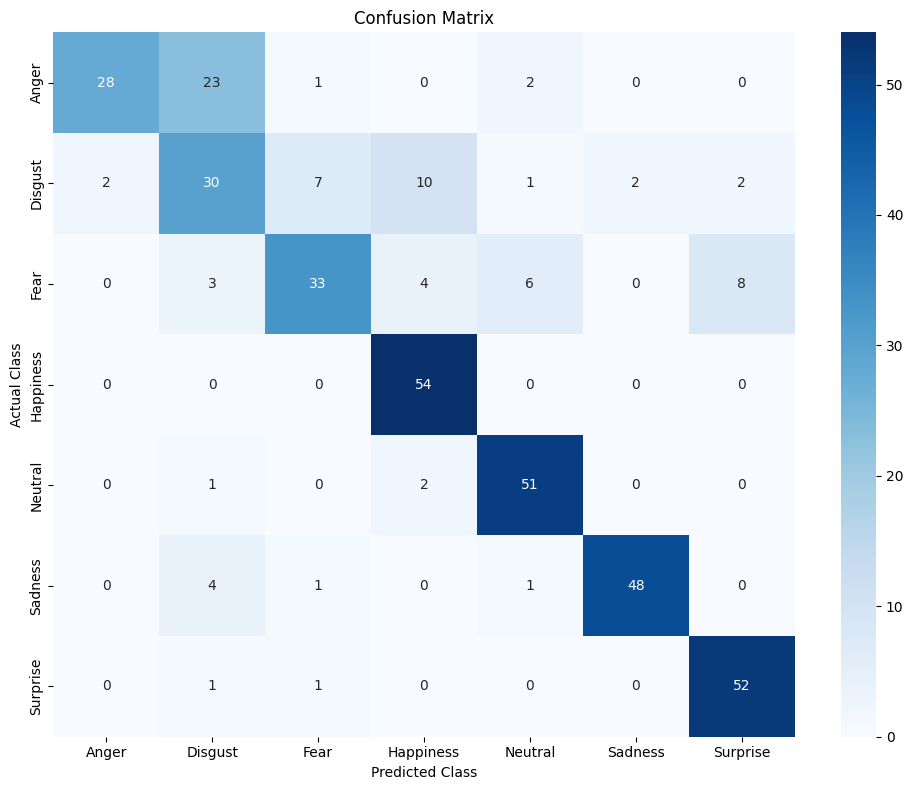

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


def plot_confusion_matrix(y_true, y_pred):
    class_names = id_to_emotion.values()

    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    fig = plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

    return fig


cm_figure = plot_confusion_matrix(y_true, y_pred)

In [19]:
def save_evaluation_results(report, cm_figure, checkpoint_dir):
    with (checkpoint_dir / 'classification_report.txt').open(mode='w') as f:
        f.write(report)
    cm_figure.savefig(str(checkpoint_dir / 'confusion_matrix.png'))


save_evaluation_results(report, cm_figure, checkpoint_dir)

In [20]:
import time

time.sleep(5)

In [21]:
def add_test_acc_to_checkpoint_dir_name(checkpoint_dir, val_acc, test_acc):
    new_name = checkpoint_dir.name + f'_val_{str(val_acc)[2:6]}_test_{str(test_acc)[2:6]}'
    new_path = checkpoint_dir.parent / new_name
    checkpoint_dir.rename(new_path)
    return new_path


new_checkpoint_dir = add_test_acc_to_checkpoint_dir_name(checkpoint_dir, val_acc, test_acc)

In [22]:
time.sleep(5)

In [23]:
import shutil

shutil.copy2((Path() / name_of_this_notebook), (new_checkpoint_dir / name_of_this_notebook))

PosixPath('20251114-1038-checkpoint-lstm-b-32-lr-5e-04-seed-31_val_8597_test_7804/lstm.ipynb')